# KDIC 검색 방식 4단계 비교·평가 노트북 — Colab 안정화판

이 노트북은 `KDIC_RAG_Crawling_v4.6`에서 생성한 **동일한 `chunks.jsonl`**과 동일한 평가 질문·Gold 청크를 고정하고, **검색 방식만 단계적으로 교체**하여 비교합니다.

| 단계 | 고정 조건 | 비교 대상 |
|---|---|---|
| 1차 | BM25 검색 공식 | Standard, Nori-none, Nori-discard, Nori-mixed |
| 2차 | 1차 Best Analyzer | BM25, BM25F |
| 2.5차 | 2차 Best Traditional Sparse | Best Traditional Sparse, BGE-M3 Sparse |
| 3차 | 2.5차 Best Sparse | BGE-M3 Dense, Best Sparse, Dense + Best Sparse Hybrid |

평가 지표는 `Hit@3`, `Recall@5`, `MRR@10`, `MAP@10`, `Complete@5`, `nDCG@5`, `Precision@5`, `F1@5`, 검색 지연시간, 컨텍스트 한도 초과율입니다.

이 노트북은 **검색 단계만 평가**합니다. 답변 생성 LLM, 질의 재작성, 재랭커, 의도별 가중치, 청크 타입 가중치는 사용하지 않습니다.


## 실험 해석 전에 고정해야 하는 규칙

1. 문서·청크·질문·Gold·Top-K를 모든 검색기에서 동일하게 사용합니다.
2. 인덱스 생성 시간과 BGE 문서 인코딩 시간은 질의 지연시간에서 제외합니다.
3. BGE-M3 Dense와 Sparse는 같은 `BAAI/bge-m3` 체크포인트, 같은 입력 문자열, 같은 `max_length`를 사용합니다.
4. Hybrid는 서로 척도가 다른 Dense·Sparse 점수를 직접 더하지 않고, 고정 가중 **RRF(Reciprocal Rank Fusion)**를 사용합니다.
5. 검색기 선택은 검증셋의 `nDCG@5`를 기본 1차 기준으로 하며, 동률이면 Recall@5 → MRR@10 → 지연시간 순으로 결정합니다.
6. 평가 CSV에 `split=validation/test`가 없다면 전체 데이터로 임시 선정합니다. 이 경우 최종 성능 보고가 아니라 **예비 실험**입니다.
7. `gold_review_status`가 `pending_review` 또는 `미지정`인 문항은 기본적으로 제외합니다. 검수되지 않은 Gold로 검색기를 고르면 승자 선정 자체가 흔들립니다.
8. 지연시간은 현재 실행 환경의 end-to-end 값입니다. Elasticsearch는 HTTP 요청, BGE-M3는 로컬 CPU/GPU 질의 인코딩을 포함하므로 서로 다른 배포 구조의 순수 알고리즘 속도로 해석하면 안 됩니다. 최종 서비스와 같은 인프라에서 다시 측정해야 합니다.

### Complete@5 주의

현재 요청을 그대로 반영하여 **주요 Gold 청크가 5개 이상인 문항에만** Complete@5를 계산합니다. 제공된 `question_results.csv` 예시는 주요 청크가 2개 이상인 일부 문항에도 Complete@5가 채워져 있으므로, 이 노트북의 재계산 결과와 예시 값이 달라질 수 있습니다.

### 구현 근거

- Nori의 `none`, `discard`, `mixed`는 Elasticsearch 공식 `nori_tokenizer`의 `decompound_mode`입니다.
- BM25F는 Elasticsearch `combined_fields`를 사용합니다. 공식 문서상 BM25F 기반의 근사 구현이며 완전한 수학적 BM25F와 100% 동일하지는 않습니다.
- BGE-M3 Sparse는 모델이 반환하는 `lexical_weights`, Dense는 `dense_vecs`를 사용합니다.

참고: [Nori tokenizer](https://www.elastic.co/docs/reference/elasticsearch/plugins/analysis-nori-tokenizer), [Elasticsearch combined_fields](https://www.elastic.co/docs/reference/query-languages/query-dsl/query-dsl-combined-fields-query), [BAAI/bge-m3](https://huggingface.co/BAAI/bge-m3)


## 0. Python 패키지 설치

`FlagEmbedding`과 `transformers`는 내부 API 의존성이 있으므로 둘 다 검증된 버전으로 고정합니다. 기존 런타임에서 다른 버전을 이미 불러왔다면 **런타임을 다시 시작한 뒤 이 셀부터 순서대로 실행**하십시오.


In [ ]:

%pip install -q \
  "elasticsearch==8.17.2" \
  "FlagEmbedding==1.4.0" \
  "transformers==4.57.6" \
  "tiktoken==0.8.0" \
  "pandas>=2.2,<3" \
  "numpy>=1.26,<3" \
  "scipy>=1.12,<2" \
  "matplotlib>=3.8,<4" \
  "seaborn>=0.13,<1"

import importlib.metadata as _package_metadata

_expected_versions = {
    "FlagEmbedding": "1.4.0",
    "transformers": "4.57.6",
}

for _package_name, _expected_version in _expected_versions.items():
    _installed_version = _package_metadata.version(_package_name)
    if _installed_version != _expected_version:
        raise RuntimeError(
            f"{_package_name} 버전 불일치: "
            f"expected={_expected_version}, installed={_installed_version}"
        )
    print(f"{_package_name}: {_installed_version}")


FlagEmbedding: 1.4.0
transformers: 4.57.6


## 1. Elasticsearch 준비

Nori는 단순 한국어 형태소 분석기 이름이 아니라 **Lucene/Elasticsearch의 Korean analysis plugin**입니다. 따라서 Nori 비교를 정확히 하려면 `analysis-nori`가 설치된 Elasticsearch가 필요합니다.

- Google Colab이면 아래 셀이 Elasticsearch 8.17.2와 같은 버전의 Nori plugin을 로컬로 설치합니다.
- 이미 Elasticsearch를 운영 중이면 `START_LOCAL_ELASTICSEARCH=False`로 바꾸고 `ES_URL`, 필요 시 인증 값을 지정합니다.
- Elastic Cloud에서 해당 plugin 사용 가능 여부는 배포 환경 설정을 확인해야 합니다.

> **Colab 호환 처리:** Colab의 cgroup v2 경로가 `/sys/fs/cgroup/../../jupyter-children`으로 해석되는 문제를 피하려고 JVM 시스템 속성 `-Des.cgroups.hierarchy.override=/`를 적용합니다. `xpack.ml.enabled: false`만으로는 핵심 `OsProbe` 오류를 해결할 수 없습니다.


In [ ]:

from __future__ import annotations

import os
import pwd
import shutil
import subprocess
import tarfile
import time
import urllib.request
from pathlib import Path

import requests

IS_COLAB = "google.colab" in __import__("sys").modules
START_LOCAL_ELASTICSEARCH = IS_COLAB
ES_VERSION = "8.17.2"
ES_URL = "http://127.0.0.1:9200"
ES_USERNAME = None
ES_PASSWORD = None

def start_colab_elasticsearch(version: str) -> None:
    install_root = Path("/content") if Path("/content").exists() else Path.cwd()

    archive_path = (
        install_root
        / f"elasticsearch-{version}-linux-x86_64.tar.gz"
    )
    es_home = install_root / f"elasticsearch-{version}"
    es_user = "kdic_es"

    # 이미 Elasticsearch가 실행 중인지 확인
    try:
        response = requests.get(ES_URL, timeout=2)
        response.raise_for_status()

        print(
            "Elasticsearch가 이미 실행 중입니다:",
            response.json()["version"]["number"],
        )
        return

    except Exception:
        pass

    # Elasticsearch 다운로드 및 압축 해제
    if not es_home.exists():
        url = (
            "https://artifacts.elastic.co/downloads/elasticsearch/"
            f"{archive_path.name}"
        )

        if not archive_path.exists():
            print("Elasticsearch 다운로드:", url)
            urllib.request.urlretrieve(url, archive_path)

        print("Elasticsearch 압축 해제 중...")

        with tarfile.open(archive_path, "r:gz") as archive:
            archive.extractall(install_root)

    # 실행용 사용자 생성
    try:
        pwd.getpwnam(es_user)
        print("기존 Elasticsearch 사용자 사용:", es_user)

    except KeyError:
        print("Elasticsearch 사용자 생성:", es_user)

        subprocess.run(
            ["useradd", "-m", es_user],
            check=True,
        )

    # Elasticsearch 설치 디렉터리 소유권 변경
    subprocess.run(
        [
            "chown",
            "-R",
            f"{es_user}:{es_user}",
            str(es_home),
        ],
        check=True,
    )

    # Nori 플러그인 설치 여부 확인
    plugin_bin = es_home / "bin" / "elasticsearch-plugin"

    plugin_list_result = subprocess.run(
        [
            "runuser",
            "-u",
            es_user,
            "--",
            str(plugin_bin),
            "list",
        ],
        check=True,
        capture_output=True,
        text=True,
    )

    installed_plugins = plugin_list_result.stdout

    if "analysis-nori" not in installed_plugins:
        print("analysis-nori 플러그인 설치 중...")

        subprocess.run(
            [
                "runuser",
                "-u",
                es_user,
                "--",
                str(plugin_bin),
                "install",
                "--batch",
                "analysis-nori",
            ],
            check=True,
        )

        print("analysis-nori 플러그인 설치 완료")

    else:
        print("analysis-nori 플러그인이 이미 설치되어 있습니다.")

    # 데이터 및 로그 경로 생성
    data_dir = install_root / "kdic-es-data"
    logs_dir = install_root / "kdic-es-logs"

    data_dir.mkdir(exist_ok=True)
    logs_dir.mkdir(exist_ok=True)

    # kdic_es 사용자가 쓸 수 있도록 소유권 변경
    subprocess.run(
        [
            "chown",
            "-R",
            f"{es_user}:{es_user}",
            str(data_dir),
            str(logs_dir),
        ],
        check=True,
    )

    # Elasticsearch 설정 작성
    config_path = es_home / "config" / "elasticsearch.yml"

    config_path.write_text(
        "\n".join(
            [
                "cluster.name: kdic-retrieval-eval",
                "node.name: kdic-node-1",
                "discovery.type: single-node",
                "xpack.security.enabled: false",
                "xpack.security.autoconfiguration.enabled: false",
                "xpack.ml.enabled: false",
                "node.roles: [master, data, ingest]",
                "network.host: 127.0.0.1",
                "http.port: 9200",
                f"path.data: {data_dir}",
                f"path.logs: {logs_dir}",
                "",
            ]
        ),
        encoding="utf-8",
    )

    subprocess.run(
        [
            "chown",
            f"{es_user}:{es_user}",
            str(config_path),
        ],
        check=True,
    )

    # 중요: /content 바로 아래가 아니라 쓰기 가능한 logs_dir 내부에 생성
    pid_path = logs_dir / "elasticsearch.pid"

    if pid_path.exists():
        pid_path.unlink()

    command = [
        "runuser",
        "-u",
        es_user,
        "--",
        "env",
        # Colab의 /proc/self/cgroup 경로가 실제 마운트 범위를 벗어나는
        # 문제를 피하기 위해 cgroup v2 루트로 강제합니다.
        "ES_JAVA_OPTS=-Xms1g -Xmx1g -Des.cgroups.hierarchy.override=/",
        str(es_home / "bin" / "elasticsearch"),
        "-d",
        "-p",
        str(pid_path),
    ]

    cgroup_cpu_stat = Path("/sys/fs/cgroup/cpu.stat")
    if cgroup_cpu_stat.exists():
        try:
            cgroup_cpu_stat.read_text(encoding="utf-8")
            print("Colab cgroup 루트 확인: 읽기 가능")
        except Exception as error:
            print("Colab cgroup 루트 확인 경고:", error)
    else:
        print("Colab cgroup 루트 확인 경고: cpu.stat 없음")

    print("Elasticsearch 실행 중...")

    result = subprocess.run(
        command,
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        print("\nElasticsearch 실행 실패")
        print("종료 코드:", result.returncode)

        if result.stdout.strip():
            print("\n[stdout]")
            print(result.stdout)

        if result.stderr.strip():
            print("\n[stderr]")
            print(result.stderr)

        print("\n로그 디렉터리:", logs_dir)

        log_files = sorted(logs_dir.glob("*.log"))

        if log_files:
            print("생성된 로그 파일:")
            for log_file in log_files:
                print("-", log_file)

        raise RuntimeError(
            f"Elasticsearch 프로세스 실행 실패: "
            f"종료 코드 {result.returncode}"
        )

    # Elasticsearch HTTP 서버 준비 대기
    for attempt in range(90):
        try:
            response = requests.get(
                ES_URL,
                timeout=2,
            )

            if response.ok:
                version_number = response.json()["version"]["number"]

                print(
                    "Elasticsearch 시작 완료:",
                    version_number,
                )
                print("PID 파일:", pid_path)
                return

        except Exception:
            pass

        if attempt % 10 == 0:
            print(
                f"Elasticsearch 시작 대기 중... "
                f"{attempt * 2}초"
            )

        time.sleep(2)

    # 시작되지 않았다면 로그 확인
    print("Elasticsearch 로그 확인:")

    for log_file in sorted(logs_dir.glob("*.log")):
        print("\n로그 파일:", log_file)

        try:
            log_lines = log_file.read_text(
                encoding="utf-8",
                errors="replace",
            ).splitlines()

            print("\n".join(log_lines[-100:]))

        except Exception as error:
            print("로그 읽기 실패:", error)

    raise RuntimeError(
        f"Elasticsearch 시작 실패. "
        f"로그를 확인하세요: {logs_dir}"
    )


# 함수 정의만 하고 넘어가지 않도록 이 셀에서 실제로 실행합니다.
if START_LOCAL_ELASTICSEARCH:
    start_colab_elasticsearch(ES_VERSION)
else:
    print("외부 Elasticsearch 사용:", ES_URL)

Elasticsearch가 이미 실행 중입니다: 8.17.2


## 2. 평가 모듈 생성


In [ ]:
%%writefile kdic_retrieval_eval.py
from __future__ import annotations

import hashlib
import json
import math
import os
import shutil
import statistics
import time
import zipfile
from collections import defaultdict
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Callable, Iterable, Mapping, Sequence

import numpy as np
import pandas as pd
from scipy import sparse


REQUIRED_EVAL_COLUMNS = {
    "question",
    "gold_primary_chunk_ids",
    "gold_supporting_chunk_ids",
    "gold_chunk_ids",
}

METRIC_COLUMNS = [
    "hit_at_3",
    "recall_at_5",
    "mrr_at_10",
    "ap_at_10",
    "complete_at_5",
    "ndcg_at_5",
    "precision_at_5",
    "f1_at_5",
]

BUSINESS_CODE_TO_LABEL = {
    "deposit_protection": "예금자보호제도",
    "deposit_insurance_payout": "예금보험금 안내",
    "unclaimed_funds": "고객 미수령금 신청",
    "mistaken_transfer": "착오송금 반환 신청",
    "debt_adjustment": "채무조정 안내",
    "hidden_assets_report": "은닉재산 신고",
}


@dataclass(frozen=True)
class ExperimentConfig:
    top_k_retrieve: int = 10
    candidate_depth: int = 50
    complete_min_primary: int = 5
    context_budget_tokens: int = 8_000
    context_top_k: int = 5
    selection_metric: str = "ndcg_at_5"
    selection_split: str = "validation"
    split_column: str = "split"
    business_filter_mode: str = "none"
    business_filter_column: str = "predicted_business_function"
    latency_repeats: int = 1
    rrf_k: int = 60
    dense_rrf_weight: float = 0.5
    sparse_rrf_weight: float = 0.5
    allowed_review_statuses: tuple[str, ...] | None = ("auto_approved", "approved")


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    with path.open("r", encoding="utf-8-sig") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(f"JSONL 파싱 실패: {path}, line={line_number}") from exc
    return rows


def safe_extract_zip(zip_path: Path, destination: Path) -> Path:
    destination = destination.resolve()
    if destination.exists():
        shutil.rmtree(destination)
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as archive:
        for member in archive.infolist():
            resolved = (destination / member.filename).resolve()
            if destination not in resolved.parents and resolved != destination:
                raise ValueError(f"안전하지 않은 ZIP 경로: {member.filename}")
        archive.extractall(destination)
    return destination


def find_unique(root: Path, filename: str, *, required: bool = True) -> Path | None:
    matches = sorted(root.rglob(filename))
    if not matches:
        if required:
            raise FileNotFoundError(f"{root} 아래에서 {filename}을 찾지 못했습니다.")
        return None
    if len(matches) > 1:
        raise RuntimeError(f"{filename}이 여러 개입니다: {matches}")
    return matches[0]


def parse_json_list(value: Any) -> list[str]:
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return []
    if isinstance(value, list):
        return [str(item).strip() for item in value if str(item).strip()]
    text = str(value).strip()
    if not text:
        return []
    try:
        parsed = json.loads(text)
    except json.JSONDecodeError:
        parsed = [part.strip() for part in text.split(",") if part.strip()]
    if not isinstance(parsed, list):
        raise ValueError(f"목록 형식이 아닙니다: {value!r}")
    return [str(item).strip() for item in parsed if str(item).strip()]


def load_chunks(data_zip: Path, work_dir: Path) -> tuple[list[dict[str, Any]], Path]:
    extracted = safe_extract_zip(data_zip, work_dir / "extracted_kdic_output")
    chunks_path = find_unique(extracted, "chunks.jsonl")
    chunks = read_jsonl(chunks_path)
    if not chunks:
        raise ValueError("chunks.jsonl이 비어 있습니다.")
    chunk_ids = [str(row.get("chunk_id", "")).strip() for row in chunks]
    if any(not chunk_id for chunk_id in chunk_ids):
        raise ValueError("빈 chunk_id가 있습니다.")
    if len(chunk_ids) != len(set(chunk_ids)):
        raise ValueError("중복 chunk_id가 있습니다.")
    return chunks, chunks_path


def load_evaluation_csv(path: Path) -> pd.DataFrame:
    last_error: Exception | None = None
    for encoding in ("utf-8-sig", "utf-8", "cp949"):
        try:
            frame = pd.read_csv(path, encoding=encoding)
            break
        except UnicodeDecodeError as exc:
            last_error = exc
    else:
        raise RuntimeError(f"CSV 인코딩을 판별하지 못했습니다: {path}") from last_error

    missing = REQUIRED_EVAL_COLUMNS - set(frame.columns)
    if missing:
        raise ValueError(f"평가 CSV 필수 열이 없습니다: {sorted(missing)}")

    for column in (
        "gold_primary_chunk_ids",
        "gold_supporting_chunk_ids",
        "gold_chunk_ids",
    ):
        frame[column] = frame[column].map(parse_json_list)

    if "evaluation_id" not in frame.columns:
        frame.insert(0, "evaluation_id", [f"Q{index:04d}" for index in range(1, len(frame) + 1)])
    if frame["evaluation_id"].astype(str).duplicated().any():
        raise ValueError("evaluation_id가 중복되었습니다.")
    if frame["question"].fillna("").astype(str).str.strip().eq("").any():
        raise ValueError("빈 question이 있습니다.")
    return frame


def validate_gold_chunk_ids(eval_df: pd.DataFrame, chunks: Sequence[Mapping[str, Any]]) -> None:
    corpus_ids = {str(chunk["chunk_id"]) for chunk in chunks}
    unknown: dict[str, list[str]] = {}
    for row in eval_df.itertuples(index=False):
        gold = set(row.gold_chunk_ids) | set(row.gold_primary_chunk_ids) | set(row.gold_supporting_chunk_ids)
        missing = sorted(gold - corpus_ids)
        if missing:
            unknown[str(row.evaluation_id)] = missing
    if unknown:
        preview = dict(list(unknown.items())[:10])
        raise ValueError(f"Gold 청크가 corpus에 없습니다. 예시={preview}, 전체 문항 수={len(unknown)}")


def filter_evaluation_rows(
    eval_df: pd.DataFrame,
    *,
    config: ExperimentConfig,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    allowed = config.allowed_review_statuses
    if not allowed or "gold_review_status" not in eval_df.columns:
        return eval_df.copy(), eval_df.iloc[0:0].copy()
    normalized = eval_df["gold_review_status"].astype(str).str.strip().str.lower()
    allowed_normalized = {str(value).strip().lower() for value in allowed}
    selected = normalized.isin(allowed_normalized)
    return eval_df.loc[selected].reset_index(drop=True), eval_df.loc[~selected].reset_index(drop=True)


def build_search_text(chunk: Mapping[str, Any]) -> str:
    parts: list[str] = []
    for field, label in (
        ("title", "제목"),
        ("section_title", "소제목"),
        ("content", "본문"),
    ):
        value = str(chunk.get(field) or "").strip()
        if value:
            parts.append(f"{label}: {value}")
    return "\n".join(parts)


def corpus_fingerprint(chunks: Sequence[Mapping[str, Any]]) -> str:
    digest = hashlib.sha256()
    for chunk in chunks:
        digest.update(str(chunk["chunk_id"]).encode("utf-8"))
        digest.update(b"\0")
        digest.update(build_search_text(chunk).encode("utf-8"))
        digest.update(b"\0")
    return digest.hexdigest()


def make_analyzer_settings(mode: str) -> dict[str, Any]:
    if mode == "standard":
        return {}
    if mode not in {"none", "discard", "mixed"}:
        raise ValueError(f"지원하지 않는 분석기 모드: {mode}")
    tokenizer_name = f"nori_{mode}_tokenizer"
    analyzer_name = f"nori_{mode}"
    return {
        "analysis": {
            "tokenizer": {
                tokenizer_name: {
                    "type": "nori_tokenizer",
                    "decompound_mode": mode,
                    "discard_punctuation": True,
                }
            },
            "analyzer": {
                analyzer_name: {
                    "type": "custom",
                    "tokenizer": tokenizer_name,
                    "filter": ["lowercase"],
                }
            },
        }
    }


def analyzer_name(mode: str) -> str:
    return "standard" if mode == "standard" else f"nori_{mode}"


def create_es_index(
    es: Any,
    *,
    index_name: str,
    analyzer_mode: str,
    chunks: Sequence[Mapping[str, Any]],
) -> None:
    if es.indices.exists(index=index_name):
        es.indices.delete(index=index_name)
    analysis = make_analyzer_settings(analyzer_mode)
    body = {
        "settings": {
            "number_of_shards": 1,
            "number_of_replicas": 0,
            "refresh_interval": "-1",
            **analysis,
        },
        "mappings": {
            "dynamic": "strict",
            "properties": {
                "chunk_id": {"type": "keyword"},
                "business_function": {"type": "keyword"},
                "title": {"type": "text", "analyzer": analyzer_name(analyzer_mode)},
                "section_title": {"type": "text", "analyzer": analyzer_name(analyzer_mode)},
                "content": {"type": "text", "analyzer": analyzer_name(analyzer_mode)},
                "search_text": {"type": "text", "analyzer": analyzer_name(analyzer_mode)},
            },
        },
    }
    es.indices.create(index=index_name, **body)

    from elasticsearch.helpers import bulk

    actions = []
    for chunk in chunks:
        actions.append(
            {
                "_index": index_name,
                "_id": str(chunk["chunk_id"]),
                "_source": {
                    "chunk_id": str(chunk["chunk_id"]),
                    "business_function": str(chunk.get("business_function") or ""),
                    "title": str(chunk.get("title") or ""),
                    "section_title": str(chunk.get("section_title") or ""),
                    "content": str(chunk.get("content") or ""),
                    "search_text": build_search_text(chunk),
                },
            }
        )
    bulk(es, actions, chunk_size=200, request_timeout=120)
    es.indices.refresh(index=index_name)
    es.indices.put_settings(index=index_name, settings={"refresh_interval": "1s"})


def inspect_analyzer_tokens(es: Any, index_name: str, text: str) -> list[str]:
    response = es.indices.analyze(
        index=index_name,
        analyzer=es.indices.get_mapping(index=index_name)[index_name]["mappings"]["properties"]["search_text"]["analyzer"],
        text=text,
    )
    return [token["token"] for token in response["tokens"]]


def _business_filter(row: Mapping[str, Any], config: ExperimentConfig) -> str | None:
    mode = config.business_filter_mode
    if mode == "none":
        return None
    if mode == "gold":
        value = row.get("gold_business_function")
        normalized = str(value).strip() if value is not None else ""
        return BUSINESS_CODE_TO_LABEL.get(normalized, normalized) or None
    if mode == "column":
        value = row.get(config.business_filter_column)
        normalized = str(value).strip() if value is not None else ""
        return BUSINESS_CODE_TO_LABEL.get(normalized, normalized) or None
    raise ValueError(f"business_filter_mode은 none/gold/column 중 하나여야 합니다: {mode}")


class ElasticsearchRetriever:
    def __init__(
        self,
        es: Any,
        *,
        index_name: str,
        method: str,
        field_boosts: Mapping[str, float] | None = None,
    ) -> None:
        if method not in {"bm25", "bm25f"}:
            raise ValueError(method)
        self.es = es
        self.index_name = index_name
        self.method = method
        self.field_boosts = dict(field_boosts or {"title": 2.0, "section_title": 1.5, "content": 1.0})

    def search(self, question: str, *, top_k: int, business_function: str | None = None) -> list[dict[str, Any]]:
        if self.method == "bm25":
            query: dict[str, Any] = {"match": {"search_text": {"query": question, "operator": "or"}}}
        else:
            fields = [f"{field}^{boost:g}" for field, boost in self.field_boosts.items()]
            query = {
                "combined_fields": {
                    "query": question,
                    "fields": fields,
                    "operator": "or",
                }
            }
        if business_function:
            query = {
                "bool": {
                    "must": [query],
                    "filter": [{"term": {"business_function": business_function}}],
                }
            }
        response = self.es.search(
            index=self.index_name,
            query=query,
            size=top_k,
            request_cache=False,
            _source=False,
        )
        return [
            {"chunk_id": hit["_id"], "score": float(hit["_score"])}
            for hit in response["hits"]["hits"]
        ]


def _l2_normalize(matrix: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return np.divide(matrix, norms, out=np.zeros_like(matrix), where=norms != 0)


@dataclass
class BGEDocumentRepresentations:
    chunk_ids: list[str]
    business_functions: list[str]
    dense: np.ndarray
    lexical_weights: list[dict[str, float]]
    model_name: str
    max_length: int
    corpus_sha256: str


def encode_bge_documents(
    chunks: Sequence[Mapping[str, Any]],
    *,
    model: Any,
    model_name: str,
    max_length: int,
    batch_size: int,
    cache_dir: Path,
) -> BGEDocumentRepresentations:
    cache_dir.mkdir(parents=True, exist_ok=True)
    fingerprint = corpus_fingerprint(chunks)
    cache_key = hashlib.sha256(
        f"{model_name}|{max_length}|{fingerprint}".encode("utf-8")
    ).hexdigest()[:20]
    metadata_path = cache_dir / f"{cache_key}_metadata.json"
    dense_path = cache_dir / f"{cache_key}_dense.npy"
    sparse_path = cache_dir / f"{cache_key}_sparse.jsonl"

    if metadata_path.exists() and dense_path.exists() and sparse_path.exists():
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        dense = np.load(dense_path)
        lexical_weights = read_jsonl(sparse_path)
        weights = [{str(k): float(v) for k, v in row["weights"].items()} for row in lexical_weights]
        return BGEDocumentRepresentations(
            chunk_ids=list(metadata["chunk_ids"]),
            business_functions=list(metadata["business_functions"]),
            dense=_l2_normalize(np.asarray(dense, dtype=np.float32)),
            lexical_weights=weights,
            model_name=metadata["model_name"],
            max_length=int(metadata["max_length"]),
            corpus_sha256=metadata["corpus_sha256"],
        )

    texts = [build_search_text(chunk) for chunk in chunks]
    encoded = model.encode(
        texts,
        batch_size=batch_size,
        max_length=max_length,
        return_dense=True,
        return_sparse=True,
        return_colbert_vecs=False,
    )
    dense = _l2_normalize(np.asarray(encoded["dense_vecs"], dtype=np.float32))
    weights = [
        {str(token_id): float(weight) for token_id, weight in record.items()}
        for record in encoded["lexical_weights"]
    ]
    metadata = {
        "model_name": model_name,
        "max_length": max_length,
        "corpus_sha256": fingerprint,
        "chunk_ids": [str(chunk["chunk_id"]) for chunk in chunks],
        "business_functions": [str(chunk.get("business_function") or "") for chunk in chunks],
    }
    metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
    np.save(dense_path, dense)
    with sparse_path.open("w", encoding="utf-8") as handle:
        for chunk, record in zip(chunks, weights):
            handle.write(
                json.dumps({"chunk_id": str(chunk["chunk_id"]), "weights": record}, ensure_ascii=False)
                + "\n"
            )
    return BGEDocumentRepresentations(
        chunk_ids=metadata["chunk_ids"],
        business_functions=metadata["business_functions"],
        dense=dense,
        lexical_weights=weights,
        model_name=model_name,
        max_length=max_length,
        corpus_sha256=fingerprint,
    )


def build_sparse_matrix(
    lexical_weights: Sequence[Mapping[str, float]],
) -> tuple[sparse.csr_matrix, dict[str, int]]:
    token_ids = sorted({str(token) for row in lexical_weights for token in row})
    token_to_column = {token: index for index, token in enumerate(token_ids)}
    row_indices: list[int] = []
    column_indices: list[int] = []
    values: list[float] = []
    for row_index, weights in enumerate(lexical_weights):
        for token, weight in weights.items():
            row_indices.append(row_index)
            column_indices.append(token_to_column[str(token)])
            values.append(float(weight))
    matrix = sparse.csr_matrix(
        (values, (row_indices, column_indices)),
        shape=(len(lexical_weights), len(token_ids)),
        dtype=np.float32,
    )
    return matrix, token_to_column


class BGERetriever:
    def __init__(
        self,
        *,
        model: Any,
        documents: BGEDocumentRepresentations,
        mode: str,
        max_length: int,
    ) -> None:
        if mode not in {"dense", "sparse"}:
            raise ValueError(mode)
        self.model = model
        self.documents = documents
        self.mode = mode
        self.max_length = max_length
        self.sparse_matrix, self.token_to_column = build_sparse_matrix(documents.lexical_weights)
        self.business_array = np.asarray(documents.business_functions)

    def _query_dense(self, question: str) -> np.ndarray:
        output = self.model.encode(
            [question],
            batch_size=1,
            max_length=self.max_length,
            return_dense=True,
            return_sparse=False,
            return_colbert_vecs=False,
        )
        vector = np.asarray(output["dense_vecs"], dtype=np.float32)
        return _l2_normalize(vector)[0]

    def _query_sparse(self, question: str) -> sparse.csr_matrix:
        output = self.model.encode(
            [question],
            batch_size=1,
            max_length=self.max_length,
            return_dense=False,
            return_sparse=True,
            return_colbert_vecs=False,
        )
        weights = output["lexical_weights"][0]
        columns: list[int] = []
        values: list[float] = []
        for token, weight in weights.items():
            column = self.token_to_column.get(str(token))
            if column is not None:
                columns.append(column)
                values.append(float(weight))
        rows = np.zeros(len(columns), dtype=np.int32)
        return sparse.csr_matrix(
            (values, (rows, columns)),
            shape=(1, self.sparse_matrix.shape[1]),
            dtype=np.float32,
        )

    def search(self, question: str, *, top_k: int, business_function: str | None = None) -> list[dict[str, Any]]:
        if self.mode == "dense":
            query = self._query_dense(question)
            scores = self.documents.dense @ query
        else:
            query = self._query_sparse(question)
            scores = (self.sparse_matrix @ query.T).toarray().ravel()
        if business_function:
            scores = scores.copy()
            scores[self.business_array != business_function] = -np.inf
        finite = np.flatnonzero(np.isfinite(scores))
        if finite.size == 0:
            return []
        order = finite[np.argsort(scores[finite])[::-1]][:top_k]
        return [
            {"chunk_id": self.documents.chunk_ids[index], "score": float(scores[index])}
            for index in order
        ]


class CachedRetriever:
    def __init__(self, rankings: Mapping[str, Sequence[Mapping[str, Any]]]) -> None:
        self.rankings = {str(key): [dict(item) for item in value] for key, value in rankings.items()}

    def search(self, question: str, *, top_k: int, business_function: str | None = None) -> list[dict[str, Any]]:
        del business_function
        return [dict(item) for item in self.rankings[str(question)][:top_k]]


class HybridRRFRetriever:
    def __init__(
        self,
        dense_retriever: Any,
        sparse_retriever: Any,
        *,
        candidate_depth: int = 50,
        rrf_k: int = 60,
        dense_weight: float = 0.5,
        sparse_weight: float = 0.5,
    ) -> None:
        self.dense_retriever = dense_retriever
        self.sparse_retriever = sparse_retriever
        self.candidate_depth = candidate_depth
        self.rrf_k = rrf_k
        self.dense_weight = dense_weight
        self.sparse_weight = sparse_weight

    def search(self, question: str, *, top_k: int, business_function: str | None = None) -> list[dict[str, Any]]:
        dense = self.dense_retriever.search(
            question, top_k=self.candidate_depth, business_function=business_function
        )
        sparse_hits = self.sparse_retriever.search(
            question, top_k=self.candidate_depth, business_function=business_function
        )
        fused: dict[str, float] = defaultdict(float)
        for rank, item in enumerate(dense, start=1):
            fused[str(item["chunk_id"])] += self.dense_weight / (self.rrf_k + rank)
        for rank, item in enumerate(sparse_hits, start=1):
            fused[str(item["chunk_id"])] += self.sparse_weight / (self.rrf_k + rank)
        ranked = sorted(fused.items(), key=lambda item: (-item[1], item[0]))[:top_k]
        return [{"chunk_id": chunk_id, "score": float(score)} for chunk_id, score in ranked]


def reciprocal_rank(retrieved: Sequence[str], relevant: set[str], k: int) -> float:
    for rank, chunk_id in enumerate(retrieved[:k], start=1):
        if chunk_id in relevant:
            return 1.0 / rank
    return 0.0


def average_precision_at_k(retrieved: Sequence[str], relevant: set[str], k: int) -> float:
    if not relevant:
        return float("nan")
    hits = 0
    total = 0.0
    for rank, chunk_id in enumerate(retrieved[:k], start=1):
        if chunk_id in relevant:
            hits += 1
            total += hits / rank
    return total / min(len(relevant), k)


def ndcg_at_k(
    retrieved: Sequence[str],
    primary: set[str],
    supporting: set[str],
    k: int,
) -> float:
    relevance = {chunk_id: 1 for chunk_id in supporting}
    relevance.update({chunk_id: 2 for chunk_id in primary})
    if not relevance:
        return float("nan")

    def dcg(values: Sequence[int]) -> float:
        return sum((2**value - 1) / math.log2(rank + 1) for rank, value in enumerate(values, start=1))

    actual = [relevance.get(chunk_id, 0) for chunk_id in retrieved[:k]]
    ideal = sorted(relevance.values(), reverse=True)[:k]
    denominator = dcg(ideal)
    return dcg(actual) / denominator if denominator else 0.0


def retrieval_metrics(
    retrieved: Sequence[str],
    *,
    primary: set[str],
    supporting: set[str],
    all_gold: set[str],
    complete_min_primary: int,
) -> dict[str, float]:
    relevant = set(all_gold) or primary | supporting
    top3 = list(retrieved[:3])
    top5 = list(retrieved[:5])
    hits5 = len(set(top5) & relevant)
    recall5 = hits5 / len(relevant) if relevant else float("nan")
    precision5 = hits5 / 5
    f1 = (
        2 * precision5 * recall5 / (precision5 + recall5)
        if precision5 + recall5 > 0
        else 0.0
    )
    complete = (
        float(primary.issubset(set(top5)))
        if len(primary) >= complete_min_primary
        else float("nan")
    )
    return {
        "hit_at_3": float(bool(set(top3) & relevant)),
        "recall_at_5": recall5,
        "mrr_at_10": reciprocal_rank(retrieved, relevant, 10),
        "ap_at_10": average_precision_at_k(retrieved, relevant, 10),
        "complete_at_5": complete,
        "ndcg_at_5": ndcg_at_k(retrieved, primary, supporting, 5),
        "precision_at_5": precision5,
        "f1_at_5": f1,
    }


def default_token_counter(text: str) -> int:
    try:
        import tiktoken

        encoding = tiktoken.get_encoding("cl100k_base")
        return len(encoding.encode(text))
    except Exception:
        return max(1, math.ceil(len(text.encode("utf-8")) / 3))


def context_text(
    retrieved_ids: Sequence[str],
    chunks_by_id: Mapping[str, Mapping[str, Any]],
    *,
    top_k: int,
) -> str:
    blocks: list[str] = []
    for rank, chunk_id in enumerate(retrieved_ids[:top_k], start=1):
        chunk = chunks_by_id[chunk_id]
        blocks.append(
            "\n".join(
                [
                    f"[근거 {rank}]",
                    f"chunk_id: {chunk_id}",
                    build_search_text(chunk),
                ]
            )
        )
    return "\n\n".join(blocks)


def evaluate_retriever(
    *,
    retriever_name: str,
    retriever: Any,
    eval_df: pd.DataFrame,
    chunks: Sequence[Mapping[str, Any]],
    config: ExperimentConfig,
    token_counter: Callable[[str], int] = default_token_counter,
) -> tuple[pd.DataFrame, dict[str, list[dict[str, Any]]]]:
    chunks_by_id = {str(chunk["chunk_id"]): chunk for chunk in chunks}
    output_rows: list[dict[str, Any]] = []
    rankings: dict[str, list[dict[str, Any]]] = {}

    for record in eval_df.to_dict(orient="records"):
        question = str(record["question"]).strip()
        business_function = _business_filter(record, config)
        repeat_results: list[tuple[float, list[dict[str, Any]]]] = []
        for _ in range(config.latency_repeats):
            started = time.perf_counter()
            hits = retriever.search(
                question,
                top_k=config.top_k_retrieve,
                business_function=business_function,
            )
            elapsed_ms = (time.perf_counter() - started) * 1000
            repeat_results.append((elapsed_ms, hits))
        repeat_results.sort(key=lambda item: item[0])
        latency_ms, hits = repeat_results[len(repeat_results) // 2]
        hits = hits[: config.top_k_retrieve]
        rankings[question] = [dict(item) for item in hits]

        retrieved_ids = [str(item["chunk_id"]) for item in hits]
        retrieved_scores = [float(item["score"]) for item in hits]
        primary = set(record["gold_primary_chunk_ids"])
        supporting = set(record["gold_supporting_chunk_ids"])
        all_gold = set(record["gold_chunk_ids"])
        metrics = retrieval_metrics(
            retrieved_ids,
            primary=primary,
            supporting=supporting,
            all_gold=all_gold,
            complete_min_primary=config.complete_min_primary,
        )
        assembled_context = context_text(
            retrieved_ids, chunks_by_id, top_k=config.context_top_k
        )
        context_tokens = token_counter(assembled_context)

        base = {
            key: value
            for key, value in record.items()
            if key
            not in {
                "retrieved_chunk_ids",
                "retrieved_scores",
                *METRIC_COLUMNS,
                "latency_ms",
                "query_embedding_cache_hit",
                "context_tokens",
                "context_limit_exceeded",
                "retriever",
            }
        }
        for column in (
            "gold_primary_chunk_ids",
            "gold_supporting_chunk_ids",
            "gold_chunk_ids",
        ):
            base[column] = json.dumps(base[column], ensure_ascii=False)
        output_rows.append(
            {
                **base,
                "retriever": retriever_name,
                "retrieved_chunk_ids": json.dumps(retrieved_ids, ensure_ascii=False),
                "retrieved_scores": json.dumps(retrieved_scores, ensure_ascii=False),
                **metrics,
                "latency_ms": latency_ms,
                "context_tokens": context_tokens,
                "context_limit_exceeded": int(context_tokens > config.context_budget_tokens),
            }
        )
    return pd.DataFrame(output_rows), rankings


def summarize_results(
    question_results: pd.DataFrame,
    *,
    group_column: str | None = None,
) -> pd.DataFrame:
    if group_column is not None and group_column not in question_results.columns:
        return pd.DataFrame()
    groups: Iterable[tuple[Any, pd.DataFrame]]
    if group_column is None:
        groups = [("ALL", question_results)]
    else:
        groups = question_results.groupby(group_column, dropna=False, sort=True)

    rows: list[dict[str, Any]] = []
    for group_value, frame in groups:
        latency = frame["latency_ms"].astype(float)
        row = {
            "group_name": group_column or "overall",
            "group_value": group_value,
            "retriever": frame["retriever"].iloc[0],
            "question_count": len(frame),
            "complete_applicable_count": int(frame["complete_at_5"].notna().sum()),
            "hit_at_3": frame["hit_at_3"].mean(),
            "recall_at_5": frame["recall_at_5"].mean(),
            "mrr_at_10": frame["mrr_at_10"].mean(),
            "map_at_10": frame["ap_at_10"].mean(),
            "complete_at_5": frame["complete_at_5"].mean(),
            "ndcg_at_5": frame["ndcg_at_5"].mean(),
            "precision_at_5": frame["precision_at_5"].mean(),
            "f1_at_5": frame["f1_at_5"].mean(),
            "latency_ms_mean": latency.mean(),
            "latency_ms_p50": latency.quantile(0.50),
            "latency_ms_p95": latency.quantile(0.95),
            "context_limit_exceeded_rate": frame["context_limit_exceeded"].mean(),
            "context_tokens_mean": frame["context_tokens"].mean(),
        }
        rows.append(row)
    return pd.DataFrame(rows)


def select_rows_for_selection(
    results: pd.DataFrame,
    *,
    config: ExperimentConfig,
) -> tuple[pd.DataFrame, str]:
    if config.split_column in results.columns:
        mask = results[config.split_column].astype(str).str.lower().eq(config.selection_split.lower())
        if mask.any():
            return results.loc[mask].copy(), config.selection_split
    return results.copy(), "all(no split column or matching split)"


def choose_best(
    method_results: Mapping[str, pd.DataFrame],
    *,
    config: ExperimentConfig,
) -> tuple[str, pd.DataFrame, str]:
    rows: list[dict[str, Any]] = []
    selection_scope = ""
    for method, results in method_results.items():
        selected, selection_scope = select_rows_for_selection(results, config=config)
        summary = summarize_results(selected).iloc[0].to_dict()
        rows.append({"method": method, **summary})
    leaderboard = pd.DataFrame(rows)
    if config.selection_metric not in leaderboard.columns:
        raise ValueError(f"선정 지표가 없습니다: {config.selection_metric}")
    leaderboard = leaderboard.sort_values(
        by=[
            config.selection_metric,
            "recall_at_5",
            "mrr_at_10",
            "latency_ms_p50",
            "method",
        ],
        ascending=[False, False, False, True, True],
        kind="mergesort",
    ).reset_index(drop=True)
    return str(leaderboard.iloc[0]["method"]), leaderboard, selection_scope


def write_method_outputs(
    *,
    output_root: Path,
    stage_name: str,
    method_name: str,
    question_results: pd.DataFrame,
    domain_column: str = "gold_business_function",
) -> dict[str, Path]:
    method_dir = output_root / stage_name / method_name
    method_dir.mkdir(parents=True, exist_ok=True)
    paths = {
        "question_results": method_dir / "question_results.csv",
        "summary_overall": method_dir / "summary_overall.csv",
        "summary_by_domain": method_dir / "summary_by_domain.csv",
    }
    question_results.to_csv(paths["question_results"], index=False, encoding="utf-8-sig")
    summarize_results(question_results).to_csv(
        paths["summary_overall"], index=False, encoding="utf-8-sig"
    )
    summarize_results(question_results, group_column=domain_column).to_csv(
        paths["summary_by_domain"], index=False, encoding="utf-8-sig"
    )
    return paths


def write_selection_log(
    path: Path,
    *,
    stage: str,
    winner: str,
    selection_scope: str,
    config: ExperimentConfig,
    leaderboard: pd.DataFrame,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "stage": stage,
        "winner": winner,
        "selection_scope": selection_scope,
        "selection_metric": config.selection_metric,
        "tie_break_order": ["recall_at_5 desc", "mrr_at_10 desc", "latency_ms_p50 asc", "method asc"],
        "config": asdict(config),
        "leaderboard": leaderboard.replace({np.nan: None}).to_dict(orient="records"),
    }
    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")


def zip_results(output_root: Path, destination: Path) -> Path:
    if destination.exists():
        destination.unlink()
    shutil.make_archive(str(destination.with_suffix("")), "zip", output_root)
    return destination


Overwriting kdic_retrieval_eval.py


## 3. 입력 파일과 실험 설정

필요한 파일은 두 개입니다.

1. v4.6 산출물 ZIP: 내부에 `chunks.jsonl`이 있어야 합니다.
2. 평가 CSV: `question`, `gold_primary_chunk_ids`, `gold_supporting_chunk_ids`, `gold_chunk_ids`가 있어야 합니다.

제공된 `question_results.csv`도 Gold 열이 있으므로 입력 평가셋으로 재사용할 수 있습니다. 기존 검색 결과와 지표 열은 읽되 새 결과로 덮어씁니다.


In [ ]:

from pathlib import Path

# Colab 왼쪽 Files에 두 파일을 업로드하면 일반적인 중복 이름까지 자동 탐색합니다.
def resolve_uploaded_file(preferred: Path, pattern: str) -> Path:
    if preferred.exists():
        return preferred
    matches = sorted(preferred.parent.glob(pattern))
    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        raise RuntimeError(
            f"입력 후보가 여러 개입니다. 하나만 남기거나 경로를 직접 지정하세요: {matches}"
        )
    return preferred


DATA_ZIP_PATH = resolve_uploaded_file(
    Path("/content/KDIC_output.zip"),
    "*KDIC_output*.zip",
)
EVAL_CSV_PATH = resolve_uploaded_file(
    Path("/content/question_results.csv"),
    "*question_results*.csv",
)

# 로컬 Jupyter 예시
# DATA_ZIP_PATH = Path("./KDIC_output(1).zip")
# EVAL_CSV_PATH = Path("./question_results.csv")

WORK_DIR = Path("./kdic_retrieval_work")
OUTPUT_ROOT = Path("./kdic_retrieval_results")

assert DATA_ZIP_PATH.exists(), f"산출물 ZIP이 없습니다: {DATA_ZIP_PATH}"
assert EVAL_CSV_PATH.exists(), f"평가 CSV가 없습니다: {EVAL_CSV_PATH}"

print("산출물 ZIP:", DATA_ZIP_PATH)
print("평가 CSV:", EVAL_CSV_PATH)


산출물 ZIP: /content/KDIC_output.zip
평가 CSV: /content/question_results.csv


In [ ]:

from kdic_retrieval_eval import ExperimentConfig

CONFIG = ExperimentConfig(
    top_k_retrieve=10,
    candidate_depth=30,              # Hybrid 후보 수: Dense/Sparse 각각 Top-30으로 고정
    complete_min_primary=5,          # 현재 요청: 주요 Gold 청크 5개 이상 문항만
    context_budget_tokens=8_000,     # 실제 답변 LLM 컨텍스트 예산에 맞게 변경
    context_top_k=5,
    selection_metric="ndcg_at_5",
    selection_split="validation",
    split_column="split",
    business_filter_mode="none",     # none 권장. gold는 oracle 실험일 뿐 최종 성능이 아님
    business_filter_column="predicted_business_function",
    latency_repeats=1,               # 최종 실험은 3~5 권장, 각 문항의 중앙값 사용
    rrf_k=60,
    dense_rrf_weight=0.5,          # 기준값. 실제 최종값은 2.75차 가중치 비교에서 선정
    sparse_rrf_weight=0.5,         # 기준값. 실제 최종값은 2.75차 가중치 비교에서 선정
    allowed_review_statuses=("auto_approved", "approved"),
)

# BM25F 필드 가중치도 검색 방식의 일부입니다. 결과를 본 뒤 test에 맞춰 바꾸면 안 됩니다.
BM25F_FIELD_BOOSTS = {
    "title": 2.0,
    "section_title": 1.5,
    "content": 1.0,
}

BGE_MODEL_NAME = "BAAI/bge-m3"
BGE_MAX_LENGTH = 1024
BGE_BATCH_SIZE = 4

CONFIG


## 4. 입력 로딩과 Gold 무결성 검사


In [ ]:

import json
import warnings

import pandas as pd

from kdic_retrieval_eval import (
    corpus_fingerprint,
    filter_evaluation_rows,
    load_chunks,
    load_evaluation_csv,
    validate_gold_chunk_ids,
)

chunks, chunks_path = load_chunks(DATA_ZIP_PATH, WORK_DIR)
full_eval_df = load_evaluation_csv(EVAL_CSV_PATH)
validate_gold_chunk_ids(full_eval_df, chunks)
eval_df, excluded_eval_df = filter_evaluation_rows(full_eval_df, config=CONFIG)

if eval_df.empty:
    raise RuntimeError("검수 상태 필터를 통과한 평가 문항이 없습니다.")

if CONFIG.split_column not in eval_df.columns:
    warnings.warn(
        "평가셋에 split 열이 없습니다. 전체 문항으로 승자를 선정하므로 결과는 예비 실험입니다. "
        "최종 실험 전 validation/test를 분리하세요."
    )

print("chunks.jsonl:", chunks_path)
print("청크 수:", len(chunks))
print("전체 평가 문항:", len(full_eval_df))
print("실험 포함 문항:", len(eval_df))
print("검수 상태로 제외된 문항:", len(excluded_eval_df))
print("Corpus SHA-256:", corpus_fingerprint(chunks))

if "gold_review_status" in full_eval_df.columns:
    display(full_eval_df["gold_review_status"].value_counts(dropna=False).rename("count").to_frame())

primary_counts = eval_df["gold_primary_chunk_ids"].map(len)
complete_applicable_count = int((primary_counts >= CONFIG.complete_min_primary).sum())
print(f"Complete@5 적용 문항 수(주요 Gold >= {CONFIG.complete_min_primary}):",
      complete_applicable_count)
if complete_applicable_count < 10:
    warnings.warn(
        f"Complete@5 적용 문항이 {complete_applicable_count}개뿐입니다. "
        "이 지표는 참고값으로만 보고, 해당 유형 문항을 확충하세요."
    )
display(eval_df.head(3))


chunks.jsonl: /content/kdic_retrieval_work/extracted_kdic_output/KDIC_output/processed/chunks.jsonl
청크 수: 427
전체 평가 문항: 113
실험 포함 문항: 66
검수 상태로 제외된 문항: 47
Corpus SHA-256: 09515b528bcbfab60a2a2befeae5220328e6d2e2eb7e10986c17e768a6162e8a


/tmp/ipykernel_481/495764551.py:23: UserWarning: 평가셋에 split 열이 없습니다. 전체 문항으로 승자를 선정하므로 결과는 예비 실험입니다. 최종 실험 전 validation/test를 분리하세요.
  warnings.warn(


,count
gold_review_status,
auto_approved,66
pending_review,39
미지정,8


Complete@5 적용 문항 수(주요 Gold >= 5): 2


/tmp/ipykernel_481/495764551.py:43: UserWarning: Complete@5 적용 문항이 2개뿐입니다. 이 지표는 참고값으로만 보고, 해당 유형 문항을 확충하세요.
  warnings.warn(


,evaluation_id,question_id_original,question,domain,gold_business_function,question_complexity,importance,gold_review_status,gold_primary_chunk_ids,gold_supporting_chunk_ids,...,hit_at_3,recall_at_5,mrr_at_10,ap_at_10,complete_at_5,ndcg_at_5,precision_at_5,f1_at_5,latency_ms,query_embedding_cache_hit
0,DP-Q001,Q001,예금자 1인당 보호받을 수 있는 한도는 얼마인가요?,예금자보호제도,deposit_protection,L1_single_fact,상,auto_approved,[DP-001_chunk_000],[],...,1.0,1.0,1.0,1.0,NaN,1.0,0.2,0.333333,1188.544,False
1,DP-Q002,Q002,한도를 초과한 금액은 어떻게 되나요?,예금자보호제도,deposit_protection,L1_single_fact,상,auto_approved,[DP-001_chunk_000],[],...,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.000000,711.589,False
2,DP-Q003,Q003,"원금과 이자를 합쳐서 계산하나요, 따로 계산하나요?",예금자보호제도,deposit_protection,L2_multi_fact,상,auto_approved,[DP-001_chunk_000],[],...,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.000000,675.147,False


## 5. Elasticsearch 연결과 분석기별 인덱스 생성

인덱스 생성 시간은 검색 지연시간에 포함하지 않습니다. 모든 인덱스는 shard 1, replica 0, 기본 BM25 파라미터를 사용합니다. 분석기 비교에서는 analyzer 외 조건을 동일하게 고정합니다.


In [ ]:

from elasticsearch import Elasticsearch

auth = (ES_USERNAME, ES_PASSWORD) if ES_USERNAME and ES_PASSWORD else None
es = Elasticsearch(
    ES_URL,
    basic_auth=auth,
    request_timeout=120,
    max_retries=3,
    retry_on_timeout=True,
)

if not es.ping():
    raise RuntimeError(f"Elasticsearch 연결 실패: {ES_URL}")

plugins = es.cat.plugins(format="json")
plugin_names = {row.get("component") for row in plugins}
if "analysis-nori" not in plugin_names:
    raise RuntimeError("analysis-nori plugin이 없습니다. Nori 비교를 진행할 수 없습니다.")

nori_probe = es.indices.analyze(
    tokenizer={
        "type": "nori_tokenizer",
        "decompound_mode": "mixed",
    },
    text="착오송금 반환지원",
)
nori_probe_tokens = [item["token"] for item in nori_probe["tokens"]]
if not nori_probe_tokens:
    raise RuntimeError("analysis-nori가 로드됐지만 토큰화 결과가 비어 있습니다.")

print("Elasticsearch:", es.info()["version"]["number"])
print("analysis-nori plugin: OK")
print("Nori 실제 토큰화: OK ->", nori_probe_tokens)


Elasticsearch: 8.17.2
analysis-nori plugin: OK
Nori 실제 토큰화: OK -> ['착오', '송금', '반환', '지원']


In [ ]:

from kdic_retrieval_eval import create_es_index, inspect_analyzer_tokens

ANALYZER_MODES = {
    "BM25_standard": "standard",
    "BM25_nori_none": "none",
    "BM25_nori_discard": "discard",
    "BM25_nori_mixed": "mixed",
}
INDEX_BY_ANALYZER = {
    mode: f"kdic-retrieval-{mode.replace('_', '-')}"
    for mode in ANALYZER_MODES.values()
}

for mode, index_name in INDEX_BY_ANALYZER.items():
    print("인덱스 생성:", mode, "->", index_name)
    create_es_index(
        es,
        index_name=index_name,
        analyzer_mode=mode,
        chunks=chunks,
    )

sample_texts = [
    "예금보험금과 착오송금 반환지원 신청 방법",
    "채무조정과 개인회생 신청 자격",
]
token_rows = []
for mode, index_name in INDEX_BY_ANALYZER.items():
    for text in sample_texts:
        token_rows.append(
            {
                "analyzer": mode,
                "text": text,
                "tokens": inspect_analyzer_tokens(es, index_name, text),
            }
        )
display(pd.DataFrame(token_rows))


인덱스 생성: standard -> kdic-retrieval-standard
인덱스 생성: none -> kdic-retrieval-none
인덱스 생성: discard -> kdic-retrieval-discard
인덱스 생성: mixed -> kdic-retrieval-mixed


,analyzer,text,tokens
0,standard,예금보험금과 착오송금 반환지원 신청 방법,"[예금보험금과, 착오송금, 반환지원, 신청, 방법]"
1,standard,채무조정과 개인회생 신청 자격,"[채무조정과, 개인회생, 신청, 자격]"
2,none,예금보험금과 착오송금 반환지원 신청 방법,"[예금, 보험금, 과, 착오, 송금, 반환, 지원, 신청, 방법]"
3,none,채무조정과 개인회생 신청 자격,"[채무조정, 과, 개인, 회생, 신청, 자격]"
4,discard,예금보험금과 착오송금 반환지원 신청 방법,"[예금, 보험, 금, 과, 착오, 송금, 반환, 지원, 신청, 방법]"
5,discard,채무조정과 개인회생 신청 자격,"[채무, 조정, 과, 개인, 회생, 신청, 자격]"
6,mixed,예금보험금과 착오송금 반환지원 신청 방법,"[예금, 보험금, 보험, 금, 과, 착오, 송금, 반환, 지원, 신청, 방법]"
7,mixed,채무조정과 개인회생 신청 자격,"[채무조정, 채무, 조정, 과, 개인, 회생, 신청, 자격]"


## 6. 공통 실행·저장 함수


In [ ]:

import re

import matplotlib.pyplot as plt
import seaborn as sns

from kdic_retrieval_eval import (
    choose_best,
    evaluate_retriever,
    summarize_results,
    write_method_outputs,
    write_selection_log,
)

all_method_results = {}
all_retrievers = {}
stage_leaderboards = {}
selection_records = {}


def safe_name(name: str) -> str:
    return re.sub(r"[^0-9A-Za-z가-힣._+-]+", "_", name).strip("_")


def evaluate_and_save(
    stage: str,
    method: str,
    retriever,
    *,
    evaluation_df=None,
):
    current_eval_df = eval_df if evaluation_df is None else evaluation_df
    print(f"[{stage}] {method} 평가 시작 (문항 수={len(current_eval_df)})")
    results, rankings = evaluate_retriever(
        retriever_name=method,
        retriever=retriever,
        eval_df=current_eval_df,
        chunks=chunks,
        config=CONFIG,
    )
    write_method_outputs(
        output_root=OUTPUT_ROOT,
        stage_name=stage,
        method_name=safe_name(method),
        question_results=results,
    )
    all_method_results[(stage, method)] = results
    all_retrievers[(stage, method)] = retriever
    print(f"[{stage}] {method} 완료")
    return results


def select_stage(stage: str, results_by_method: dict):
    winner, leaderboard, scope = choose_best(results_by_method, config=CONFIG)
    leaderboard.to_csv(
        OUTPUT_ROOT / stage / "leaderboard.csv",
        index=False,
        encoding="utf-8-sig",
    )
    write_selection_log(
        OUTPUT_ROOT / stage / "selection_log.json",
        stage=stage,
        winner=winner,
        selection_scope=scope,
        config=CONFIG,
        leaderboard=leaderboard,
    )
    stage_leaderboards[stage] = leaderboard
    selection_records[stage] = {
        "winner": winner,
        "selection_scope": scope,
    }
    print("선정 범위:", scope)
    print("승자:", winner)
    display(
        leaderboard[
            [
                "method",
                "ndcg_at_5",
                "recall_at_5",
                "mrr_at_10",
                "map_at_10",
                "latency_ms_p50",
                "context_limit_exceeded_rate",
            ]
        ]
    )
    return winner


def plot_leaderboard(stage: str):
    frame = stage_leaderboards[stage].copy()
    plot_frame = frame.melt(
        id_vars="method",
        value_vars=["hit_at_3", "recall_at_5", "mrr_at_10", "map_at_10", "ndcg_at_5"],
        var_name="metric",
        value_name="score",
    )
    plt.figure(figsize=(12, 5))
    sns.barplot(data=plot_frame, x="metric", y="score", hue="method")
    plt.ylim(0, 1)
    plt.title(stage)
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    chart_path = OUTPUT_ROOT / stage / "metric_comparison.png"
    plt.savefig(chart_path, dpi=160, bbox_inches="tight")
    plt.show()


## 7. 1차 비교 — BM25 분석기 선택


[stage_1_analyzer] BM25_standard 평가 시작
[stage_1_analyzer] BM25_standard 완료
[stage_1_analyzer] BM25_nori_none 평가 시작
[stage_1_analyzer] BM25_nori_none 완료
[stage_1_analyzer] BM25_nori_discard 평가 시작
[stage_1_analyzer] BM25_nori_discard 완료
[stage_1_analyzer] BM25_nori_mixed 평가 시작
[stage_1_analyzer] BM25_nori_mixed 완료
선정 범위: all(no split column or matching split)
승자: BM25_nori_none


,method,ndcg_at_5,recall_at_5,mrr_at_10,map_at_10,latency_ms_p50,context_limit_exceeded_rate
0,BM25_nori_none,0.332925,0.458081,0.315458,0.304621,6.928423,0.0
1,BM25_nori_mixed,0.317804,0.430303,0.313594,0.286706,7.004913,0.0
2,BM25_nori_discard,0.299790,0.437374,0.290398,0.268839,5.591626,0.0
3,BM25_standard,0.126317,0.193434,0.132359,0.114877,6.512191,0.0


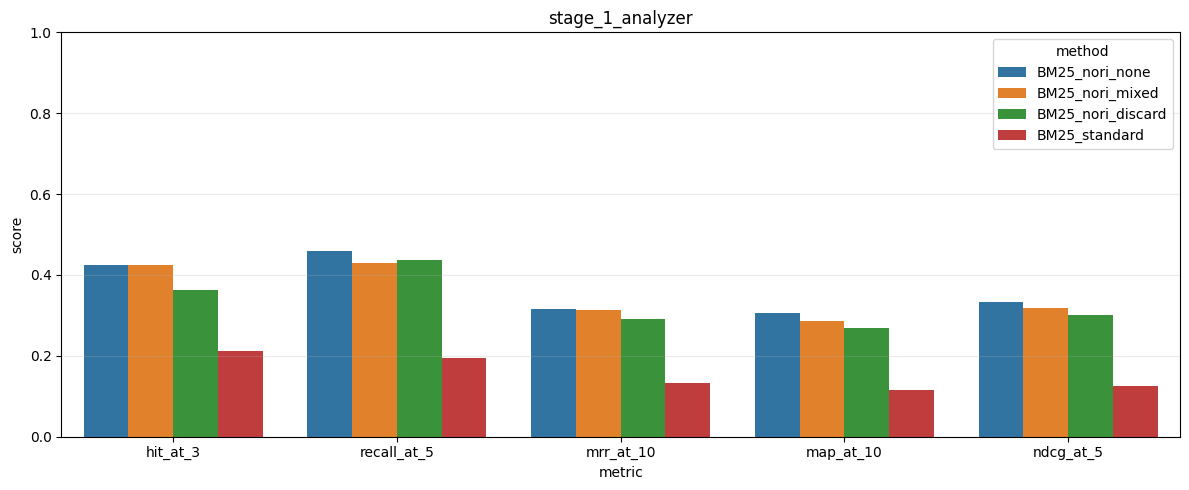

In [ ]:

from kdic_retrieval_eval import ElasticsearchRetriever

stage1_results = {}
stage1_retrievers = {}

for method_name, mode in ANALYZER_MODES.items():
    retriever = ElasticsearchRetriever(
        es,
        index_name=INDEX_BY_ANALYZER[mode],
        method="bm25",
    )
    stage1_retrievers[method_name] = retriever
    stage1_results[method_name] = evaluate_and_save(
        "stage_1_analyzer",
        method_name,
        retriever,
    )

best_analyzer_method = select_stage("stage_1_analyzer", stage1_results)
best_analyzer_mode = ANALYZER_MODES[best_analyzer_method]
plot_leaderboard("stage_1_analyzer")


## 8. 2차 비교 — BM25 vs BM25F

BM25F는 `title`, `section_title`, `content`를 분리한 뒤 `combined_fields`로 검색합니다. 필드 가중치는 위 설정 셀에서 미리 고정한 값을 사용합니다.


[stage_2_traditional_sparse] BM25_none 평가 시작
[stage_2_traditional_sparse] BM25_none 완료
[stage_2_traditional_sparse] BM25F_none 평가 시작
[stage_2_traditional_sparse] BM25F_none 완료
선정 범위: all(no split column or matching split)
승자: BM25F_none


,method,ndcg_at_5,recall_at_5,mrr_at_10,map_at_10,latency_ms_p50,context_limit_exceeded_rate
0,BM25F_none,0.345703,0.459596,0.340332,0.326679,5.255801,0.0
1,BM25_none,0.332925,0.458081,0.315458,0.304621,4.488156,0.0


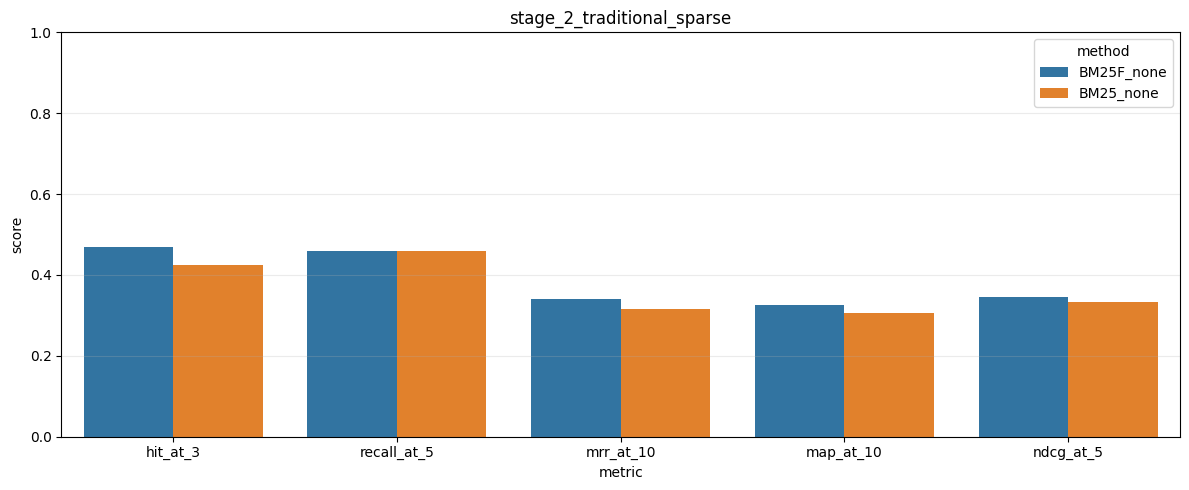

In [ ]:

best_bm25_retriever = stage1_retrievers[best_analyzer_method]
bm25f_method_name = f"BM25F_{best_analyzer_mode}"
bm25_method_name = f"BM25_{best_analyzer_mode}"

stage2_retrievers = {
    bm25_method_name: best_bm25_retriever,
    bm25f_method_name: ElasticsearchRetriever(
        es,
        index_name=INDEX_BY_ANALYZER[best_analyzer_mode],
        method="bm25f",
        field_boosts=BM25F_FIELD_BOOSTS,
    ),
}
stage2_results = {
    method: evaluate_and_save("stage_2_traditional_sparse", method, retriever)
    for method, retriever in stage2_retrievers.items()
}

best_traditional_method = select_stage("stage_2_traditional_sparse", stage2_results)
best_traditional_retriever = stage2_retrievers[best_traditional_method]
plot_leaderboard("stage_2_traditional_sparse")


## 9. BGE-M3 문서 표현 생성

v4.6의 HCX Dense 임베딩 파일은 BGE-M3 Sparse의 `lexical_weights`를 포함하지 않습니다. Dense와 Sparse를 같은 모델 구현·전처리 조건으로 비교하기 위해 이 셀에서 `BAAI/bge-m3`로 두 표현을 함께 다시 생성합니다.

생성 결과는 corpus fingerprint, 모델명, `max_length`를 키로 캐시합니다. 문서 인코딩 시간은 온라인 질의 지연시간에 포함하지 않습니다.


In [ ]:

import torch
from FlagEmbedding import BGEM3FlagModel

from kdic_retrieval_eval import BGERetriever, encode_bge_documents

use_fp16 = bool(torch.cuda.is_available())
print("CUDA:", torch.cuda.is_available(), "| use_fp16:", use_fp16)

bge_model = BGEM3FlagModel(
    BGE_MODEL_NAME,
    use_fp16=use_fp16,
)
bge_documents = encode_bge_documents(
    chunks,
    model=bge_model,
    model_name=BGE_MODEL_NAME,
    max_length=BGE_MAX_LENGTH,
    batch_size=BGE_BATCH_SIZE,
    cache_dir=WORK_DIR / "bge_cache",
)

bge_sparse_retriever = BGERetriever(
    model=bge_model,
    documents=bge_documents,
    mode="sparse",
    max_length=BGE_MAX_LENGTH,
)
bge_dense_retriever = BGERetriever(
    model=bge_model,
    documents=bge_documents,
    mode="dense",
    max_length=BGE_MAX_LENGTH,
)

print("Dense shape:", bge_documents.dense.shape)
print("Sparse document count:", len(bge_documents.lexical_weights))


CUDA: True | use_fp16: True


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

...

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

sparse_linear.pt:   0%|          | 0.00/3.52k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

pre tokenize: 100%|██████████| 107/107 [00:00<00:00, 275.69it/s]
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
Inference Embeddings: 100%|██████████| 107/107 [00:04<00:00, 26.63it/s]


Dense shape: (427, 1024)
Sparse document count: 427


## 10. 2.5차 비교 — Best Traditional Sparse vs BGE-M3 Sparse


[stage_2_5_sparse_family] BM25F_none 평가 시작
[stage_2_5_sparse_family] BM25F_none 완료
[stage_2_5_sparse_family] BGE-M3_Sparse 평가 시작


Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 52.46it/s]


[stage_2_5_sparse_family] BGE-M3_Sparse 완료
선정 범위: all(no split column or matching split)
승자: BGE-M3_Sparse


,method,ndcg_at_5,recall_at_5,mrr_at_10,map_at_10,latency_ms_p50,context_limit_exceeded_rate
0,BGE-M3_Sparse,0.473864,0.612121,0.474555,0.424602,47.466310,0.0
1,BM25F_none,0.345703,0.459596,0.340332,0.326679,4.840805,0.0


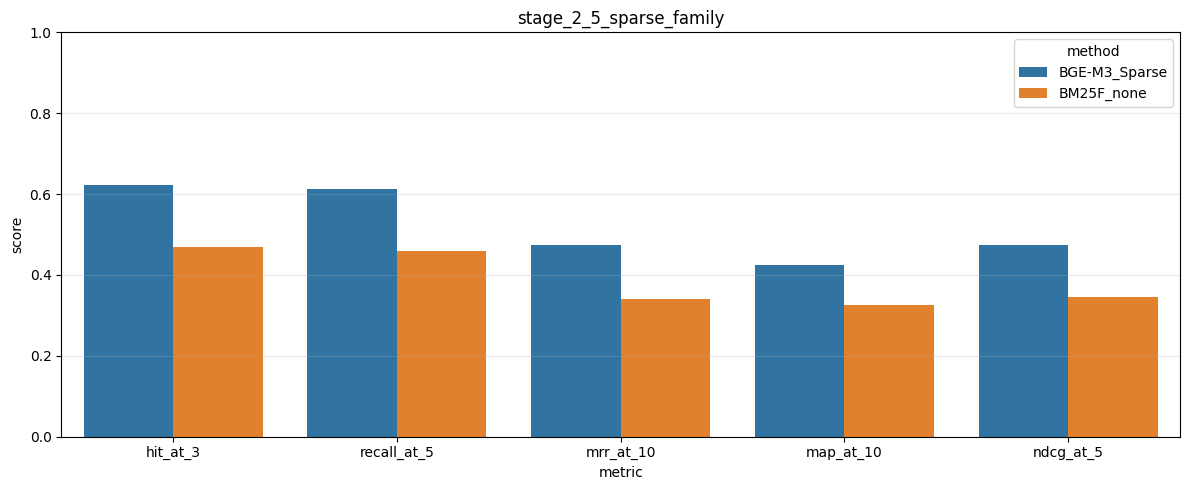

In [ ]:

stage25_retrievers = {
    best_traditional_method: best_traditional_retriever,
    "BGE-M3_Sparse": bge_sparse_retriever,
}
stage25_results = {
    method: evaluate_and_save("stage_2_5_sparse_family", method, retriever)
    for method, retriever in stage25_retrievers.items()
}

best_sparse_method = select_stage("stage_2_5_sparse_family", stage25_results)
best_sparse_retriever = stage25_retrievers[best_sparse_method]
plot_leaderboard("stage_2_5_sparse_family")


## 11. 2.75차 비교 — Hybrid RRF 가중치 선정

2.5차에서 선정된 `Best Sparse`와 `BGE-M3 Dense`를 결합합니다.

이 단계에서는 다음 조건을 고정하고 **Dense/Sparse의 RRF 기여 가중치만 변경**합니다.

- Dense 후보 수: Top-30
- Sparse 후보 수: Top-30
- `candidate_depth=30`
- `RRF_K=60`
- 최종 반환 수: `CONFIG.top_k_retrieve`
- 선정 지표: `CONFIG.selection_metric`
- 선정 데이터: validation split이 있으면 validation만 사용

비교 후보는 Dense:Sparse 기준 `0.2:0.8`부터 `0.8:0.2`까지이며, 선정된 가중치는 다음 3차 최종 비교의 Hybrid에 자동 적용됩니다.


In [ ]:
from kdic_retrieval_eval import HybridRRFRetriever

# Hybrid 가중치 비교에서는 후보 깊이를 반드시 30으로 고정합니다.
HYBRID_CANDIDATE_DEPTH = 30
if CONFIG.candidate_depth != HYBRID_CANDIDATE_DEPTH:
    raise ValueError(
        "CONFIG.candidate_depth와 HYBRID_CANDIDATE_DEPTH가 다릅니다: "
        f"{CONFIG.candidate_depth} != {HYBRID_CANDIDATE_DEPTH}"
    )

# 1.0:0.0과 0.0:1.0은 Dense/Sparse 단독과 중복되므로 제외합니다.
HYBRID_WEIGHT_CANDIDATES = [
    (0.2, 0.8),
    (0.3, 0.7),
    (0.4, 0.6),
    (0.5, 0.5),
    (0.6, 0.4),
    (0.7, 0.3),
    (0.8, 0.2),
]

for dense_weight, sparse_weight in HYBRID_WEIGHT_CANDIDATES:
    if abs((dense_weight + sparse_weight) - 1.0) > 1e-9:
        raise ValueError(
            f"가중치 합이 1이 아닙니다: dense={dense_weight}, sparse={sparse_weight}"
        )

# 가중치 선택에는 validation만 사용합니다. split이 없으면 전체 문항을 사용합니다.
hybrid_tuning_eval_df = eval_df
hybrid_tuning_scope = "all(no validation split)"
if CONFIG.split_column in eval_df.columns:
    validation_mask = (
        eval_df[CONFIG.split_column]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq(CONFIG.selection_split.lower())
    )
    if validation_mask.any():
        hybrid_tuning_eval_df = eval_df.loc[validation_mask].reset_index(drop=True)
        hybrid_tuning_scope = CONFIG.selection_split

print("Hybrid 가중치 선정 범위:", hybrid_tuning_scope)
print("Hybrid 가중치 선정 문항 수:", len(hybrid_tuning_eval_df))
print("candidate_depth:", HYBRID_CANDIDATE_DEPTH)
print("rrf_k:", CONFIG.rrf_k)

hybrid_weight_retrievers = {}
hybrid_weight_lookup = {}

for dense_weight, sparse_weight in HYBRID_WEIGHT_CANDIDATES:
    method_name = (
        f"Hybrid_RRF_D{dense_weight:.1f}_S{sparse_weight:.1f}"
        f"__Depth{HYBRID_CANDIDATE_DEPTH}"
    )
    hybrid_weight_retrievers[method_name] = HybridRRFRetriever(
        bge_dense_retriever,
        best_sparse_retriever,
        candidate_depth=HYBRID_CANDIDATE_DEPTH,
        rrf_k=CONFIG.rrf_k,
        dense_weight=dense_weight,
        sparse_weight=sparse_weight,
    )
    hybrid_weight_lookup[method_name] = (dense_weight, sparse_weight)

hybrid_weight_results = {
    method: evaluate_and_save(
        "stage_2_75_hybrid_weight",
        method,
        retriever,
        evaluation_df=hybrid_tuning_eval_df,
    )
    for method, retriever in hybrid_weight_retrievers.items()
}

best_hybrid_weight_method = select_stage(
    "stage_2_75_hybrid_weight",
    hybrid_weight_results,
)
best_hybrid_dense_weight, best_hybrid_sparse_weight = hybrid_weight_lookup[
    best_hybrid_weight_method
]
best_hybrid_weight_retriever = hybrid_weight_retrievers[
    best_hybrid_weight_method
]

print("Best Hybrid 가중치 방법:", best_hybrid_weight_method)
print("Best Dense 가중치:", best_hybrid_dense_weight)
print("Best Sparse 가중치:", best_hybrid_sparse_weight)
plot_leaderboard("stage_2_75_hybrid_weight")


## 12. 3차 비교 — Dense vs Best Sparse vs Best Weighted Hybrid

2.75차에서 validation 기준으로 선정된 RRF 가중치를 사용해 최종 Hybrid를 다시 구성합니다.

최종 비교 후보:

1. `BGE-M3 Dense`
2. `Best Sparse`
3. `BGE-M3 Dense + Best Sparse Hybrid`

Hybrid는 Dense/Sparse 각각 Top-30을 가져오고, `RRF_K=60`과 2.75차 선정 가중치로 결합합니다.


In [ ]:
from kdic_retrieval_eval import HybridRRFRetriever

hybrid_method = (
    f"Hybrid_BGE-Dense+{best_sparse_method}"
    f"__D{best_hybrid_dense_weight:.1f}_S{best_hybrid_sparse_weight:.1f}"
    f"__Depth{HYBRID_CANDIDATE_DEPTH}"
)

hybrid_retriever = HybridRRFRetriever(
    bge_dense_retriever,
    best_sparse_retriever,
    candidate_depth=HYBRID_CANDIDATE_DEPTH,
    rrf_k=CONFIG.rrf_k,
    dense_weight=best_hybrid_dense_weight,
    sparse_weight=best_hybrid_sparse_weight,
)

print("최종 Hybrid 설정")
print("- candidate_depth:", HYBRID_CANDIDATE_DEPTH)
print("- rrf_k:", CONFIG.rrf_k)
print("- dense_weight:", best_hybrid_dense_weight)
print("- sparse_weight:", best_hybrid_sparse_weight)

stage3_retrievers = {
    "BGE-M3_Dense": bge_dense_retriever,
    f"Best_Sparse__{best_sparse_method}": best_sparse_retriever,
    hybrid_method: hybrid_retriever,
}
stage3_results = {
    method: evaluate_and_save("stage_3_final_family", method, retriever)
    for method, retriever in stage3_retrievers.items()
}

best_final_method = select_stage("stage_3_final_family", stage3_results)
best_final_retriever = stage3_retrievers[best_final_method]
plot_leaderboard("stage_3_final_family")


## 13. 단계별 승자와 최종 결과 패키징


In [ ]:

import importlib.metadata
from datetime import datetime, timezone

from kdic_retrieval_eval import corpus_fingerprint, zip_results

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

all_leaderboards = []
for stage, leaderboard in stage_leaderboards.items():
    current = leaderboard.copy()
    current.insert(0, "stage", stage)
    all_leaderboards.append(current)
consolidated = pd.concat(all_leaderboards, ignore_index=True)
consolidated.to_csv(
    OUTPUT_ROOT / "all_stage_leaderboards.csv",
    index=False,
    encoding="utf-8-sig",
)

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "corpus_sha256": corpus_fingerprint(chunks),
    "chunk_count": len(chunks),
    "evaluation_question_count": len(eval_df),
    "excluded_question_count": len(excluded_eval_df),
    "config": CONFIG.__dict__,
    "selected_hybrid_config": {
        "candidate_depth": HYBRID_CANDIDATE_DEPTH,
        "rrf_k": CONFIG.rrf_k,
        "dense_weight": best_hybrid_dense_weight,
        "sparse_weight": best_hybrid_sparse_weight,
        "selection_method": best_hybrid_weight_method,
        "selection_scope": hybrid_tuning_scope,
        "weight_candidates": [
            {"dense": dense, "sparse": sparse}
            for dense, sparse in HYBRID_WEIGHT_CANDIDATES
        ],
    },
    "bm25f_field_boosts": BM25F_FIELD_BOOSTS,
    "bge_model_name": BGE_MODEL_NAME,
    "bge_max_length": BGE_MAX_LENGTH,
    "selections": selection_records,
    "final_winner": best_final_method,
    "versions": {
        "elasticsearch_server": es.info()["version"]["number"],
        "elasticsearch_python": importlib.metadata.version("elasticsearch"),
        "FlagEmbedding": importlib.metadata.version("FlagEmbedding"),
        "transformers": importlib.metadata.version("transformers"),
        "numpy": importlib.metadata.version("numpy"),
        "pandas": importlib.metadata.version("pandas"),
    },
}
(OUTPUT_ROOT / "run_manifest.json").write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

zip_path = zip_results(OUTPUT_ROOT, Path("./KDIC_retrieval_evaluation_results.zip"))

print("1차 Best Analyzer:", best_analyzer_mode)
print("2차 Best Traditional Sparse:", best_traditional_method)
print("2.5차 Best Sparse:", best_sparse_method)
print("2.75차 Best Hybrid 가중치:", best_hybrid_weight_method)
print(
    "선정 가중치:",
    f"Dense={best_hybrid_dense_weight:.1f},",
    f"Sparse={best_hybrid_sparse_weight:.1f},",
    f"candidate_depth={HYBRID_CANDIDATE_DEPTH}",
)
print("3차 최종 승자:", best_final_method)
print("결과 ZIP:", zip_path.resolve())

display(
    stage_leaderboards["stage_3_final_family"][
        [
            "method",
            "hit_at_3",
            "recall_at_5",
            "mrr_at_10",
            "map_at_10",
            "complete_at_5",
            "ndcg_at_5",
            "precision_at_5",
            "f1_at_5",
            "latency_ms_mean",
            "latency_ms_p50",
            "latency_ms_p95",
            "context_limit_exceeded_rate",
        ]
    ]
)


In [ ]:

# Colab에서 결과 ZIP 다운로드
if IS_COLAB:
    from google.colab import files
    files.download(str(zip_path))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 14. 실패 문항 분석

평균 지표만으로는 왜 실패했는지 알 수 없습니다. 최종 승자의 `question_results.csv`에서 다음 순서로 확인합니다.

1. `hit_at_3=0`: 핵심 근거가 상위 3개에 전혀 없는 문항
2. `recall_at_5<1`: 복수 근거 중 일부를 놓친 문항
3. `ndcg_at_5`가 낮은 문항: 주요 청크가 지원 청크보다 뒤로 밀린 문항
4. `context_limit_exceeded=1`: 검색은 성공해도 답변 LLM 입력이 과도한 문항
5. 업무별 summary: 특정 업무에서만 형태소 분석이나 청크 구조 문제가 반복되는지 확인


In [ ]:

final_results = stage3_results[best_final_method].copy()
failure_columns = [
    column
    for column in [
        "evaluation_id",
        "question",
        "gold_business_function",
        "question_complexity",
        "gold_chunk_ids",
        "retrieved_chunk_ids",
        "hit_at_3",
        "recall_at_5",
        "mrr_at_10",
        "ndcg_at_5",
        "context_tokens",
        "context_limit_exceeded",
    ]
    if column in final_results.columns
]
failures = final_results.sort_values(
    ["hit_at_3", "recall_at_5", "ndcg_at_5", "mrr_at_10"],
    ascending=[True, True, True, True],
)
display(failures[failure_columns].head(30))


,evaluation_id,question,gold_business_function,question_complexity,gold_chunk_ids,retrieved_chunk_ids,hit_at_3,recall_at_5,mrr_at_10,ndcg_at_5,context_tokens,context_limit_exceeded
1,DP-Q002,한도를 초과한 금액은 어떻게 되나요?,deposit_protection,L1_single_fact,"[""DP-001_chunk_000""]","[""MT-010_rule_layer01_chunk_038"", ""DP-006_chun...",0.0,0.000000,0.000000,0.000000,1279,0
2,DP-Q003,"원금과 이자를 합쳐서 계산하나요, 따로 계산하나요?",deposit_protection,L2_multi_fact,"[""DP-001_chunk_000""]","[""DP-006_chunk_008"", ""DA-003_chunk_005"", ""DP-0...",0.0,0.000000,0.000000,0.000000,2139,0
3,DP-Q007,어떤 금융회사가 예금보호 대상인가요?,deposit_protection,L2_multi_fact,"[""DP-003_chunk_001"", ""DP-003_chunk_002""]","[""DP-006_chunk_002"", ""DP-003_chunk_003"", ""DP-0...",0.0,0.000000,0.000000,0.000000,1874,0
4,DP-Q008,상호저축은행도 보호되나요?,deposit_protection,L2_multi_fact,"[""DP-003_chunk_001"", ""DP-003_chunk_002""]","[""DP-004_chunk_010"", ""DP-004_chunk_011"", ""DP-0...",0.0,0.000000,0.000000,0.000000,1581,0
5,DP-Q009,증권사는 예금보호 대상에 포함되나요?,deposit_protection,L2_multi_fact,"[""DP-003_chunk_002""]","[""DP-003_chunk_003"", ""DP-003_chunk_000"", ""DP-0...",0.0,0.000000,0.000000,0.000000,1963,0
10,BI-Q024,보험사고 발생 후 지급까지 얼마나 걸리나요?,deposit_insurance_payout,L1_single_fact,"[""BI-002_chunk_002""]","[""BI-003_chunk_005"", ""BI-004_chunk_013"", ""DP-0...",0.0,0.000000,0.000000,0.000000,1720,0
24,UN-Q145,돈 안찾아간 거 있는지 어떻게 확인해?,unclaimed_funds,L1_single_fact,"[""UN-003_chunk_006""]","[""UN-001_chunk_000"", ""DP-005_chunk_018"", ""UN-0...",0.0,0.000000,0.000000,0.000000,1035,0
31,MT-Q050,반환에 동의하지 않으면 어떻게 되나요?,mistaken_transfer,L3_conditional,"[""MT-006_chunk_000""]","[""MT-010_rule_layer01_chunk_030"", ""MT-010_rule...",0.0,0.000000,0.000000,0.000000,1826,0
44,MT-Q067,제가 반환지원 신청대상인지 어떻게 확인하나요?,mistaken_transfer,L2_multi_fact,"[""MT-013_chunk_000"", ""MT-013_chunk_002"", ""MT-0...","[""MT-010_rule_layer01_chunk_019"", ""MT-010_rule...",0.0,0.000000,0.000000,0.000000,2158,0
65,HA-Q094,은닉재산 신고와 불법행위 신고는 어떻게 다른가요?,hidden_assets_report,L2_multi_fact,"[""HP-003_chunk_000"", ""HP-003_chunk_001""]","[""HP-002_chunk_009"", ""HP-002_chunk_003"", ""HP-0...",0.0,0.000000,0.000000,0.000000,1293,0


## 결과 파일 구조

```text
kdic_retrieval_results/
├─ stage_1_analyzer/
│  ├─ <method>/question_results.csv
│  ├─ <method>/summary_overall.csv
│  ├─ <method>/summary_by_domain.csv
│  ├─ leaderboard.csv
│  └─ selection_log.json
├─ stage_2_traditional_sparse/
├─ stage_2_5_sparse_family/
├─ stage_2_75_hybrid_weight/
├─ stage_3_final_family/
├─ all_stage_leaderboards.csv
└─ run_manifest.json
```

`stage_2_75_hybrid_weight`에는 `candidate_depth=30`으로 고정한 가중치별 결과와 validation 기준 선정 기록이 저장됩니다.

`question_results.csv`는 제공된 예시와 동일하게 문항별 Gold, 검색 청크, 점수, 지표, 지연시간을 보존합니다.
